# ex03) 여러 가지 조합을 통한 다중분류 실습 (Fashion-MNIST)

> **한 줄 요약** : 활성화 함수 + 최적화 함수 **조합을 바꿔가며 성능을 비교**하는 것이 딥러닝 튜닝의 기본.

## 오늘의 흐름
| 단계 | 내용 |
|---|---|
| 1 | 최적화 함수(Optimizer) 종류 정리 - SGD / Momentum / Adagrad / Adam |
| 2 | Fashion-MNIST 데이터 불러오기 & 탐색 |
| 3 | 원핫인코딩 |
| 4 | 조합별 신경망 설계 및 학습 |
| 5 | 결과 시각화 및 비교 |

## 꼭 기억할 키워드
`Optimizer` `SGD` `Momentum` `Adagrad` `Adam` `Flatten` `softmax` `원핫인코딩` `baseline 비교`


# 1. 실습 목표

여러 가지 **활성화 함수(activation)** 와 **최적화 함수(optimizer)** 를 조합해서
가장 성능이 좋은 조합을 찾아내는 실습

- 지금까지 배운 `sigmoid` 외에 다른 활성화 함수도 사용해보기 (`tanh`, `relu` ...)
- 오차를 잘 줄일 수 있도록 **학습 방법을 설정하는 `optimizer`** 와 **`loss` 함수** 설정하기

> 딥러닝에는 "이게 정답"인 조합이 없다. **데이터마다 다르므로 직접 비교해봐야 한다.**


## 2. 최적화 함수 (Optimizer)

- 오차를 확인하여 **어떻게 하면 오차를 줄일 수 있는지** 분석해 학습 방법을 설정하는 함수
- 손실함수의 **기울기(미분값)** 를 구해, 오차가 낮아지는 방향으로 w를 이동시켜 최적값을 찾는다

> 산에서 내려올 때 "어느 방향으로, 얼마나 큰 보폭으로" 내려갈지 정하는 전략이라고 생각하면 쉽다.
> - **방향**을 개선한 것 → Momentum
> - **보폭(학습률)** 을 개선한 것 → Adagrad
> - **둘 다** 개선한 것 → Adam


### 2-1. SGD (확률적 경사하강법, Stochastic Gradient Descent)

- 오차를 줄여나갈 수 있도록 **확률적으로 선택된 일부 데이터**만 사용해 가중치를 업데이트하는 방법
- 기울기를 구해 가중치 값을 늘리거나 줄이는 방법으로 계산 진행 (**이전 방향은 신경쓰지 않음**)
- 방향을 고려하지 않기 때문에 **지그재그 현상**이 발생할 가능성이 높음 → 최적점까지 오래 걸림

```python
model.compile(optimizer='SGD', ...)
```


### 2-2. 모멘텀 (Momentum)

- 경사하강법으로 가중치를 수정할 때 **이전에 움직이던 방향(관성)까지 참고**해서 업데이트
- 지그재그 현상이 줄어들어 최적의 지점을 찾아내는 **속도가 빨라질 가능성**이 있다
- 사용방법 : `momentum` 지수를 보통 **0.9** 로 설정

```python
from tensorflow.keras.optimizers import SGD
model.compile(optimizer=SGD(momentum=0.9), ...)
```


### 2-3. Adagrad

- 학습을 진행하면서 **학습률(보폭)을 점차 줄여나가는** 방법
- 처음에는 학습률을 크게 하여 가중치 변동을 크게 → 점점 작게 학습
  → 최적의 해 근처에서 **훌쩍 뛰어넘어 버리는 문제를 방지**
- 학습 속도가 빠르고, 최적의 해를 놓치지 않고 찾을 수 있다는 장점


### 2-4. Adam ⭐

- 학습률을 점차 줄여나가면서(**Adagrad**) + 이전의 방향까지 참고해서(**Momentum**) 최적의 해를 찾는 방법
- 두 방법의 장점을 모아놓은 것으로 **현재 가장 많이 사용**하는 최적화 함수
- 특별한 이유가 없다면 일단 `Adam` 부터 써보면 된다

| Optimizer | 방향 보정 | 학습률 조절 |
|---|:---:|:---:|
| SGD | ❌ | ❌ |
| Momentum | ⭕ | ❌ |
| Adagrad | ❌ | ⭕ |
| **Adam** | **⭕** | **⭕** |


## 3. Tensorflow에서 제공하는 패션 데이터(Fashion-MNIST)로 학습

- Tensorflow에서 제공하는 **패션 이미지 데이터**를 활용하여 다중분류 모델 학습 진행
- 여러 가지 활성화 함수와 최적화 함수를 사용하여 **최적의 조합**을 찾아내보기
- 구조는 MNIST와 완전히 동일 (28 x 28 흑백, 10개 클래스) 하지만 **훨씬 어려운 데이터**
  - 숫자와 달리 옷 모양은 서로 비슷해서(셔츠 vs 코트 vs 스웨터) 정확도가 낮게 나온다


In [1]:
# 데이터 분석 3종 세트 불러오기
import pandas as pd             # 원핫인코딩(get_dummies)에 사용
import numpy as np              # 정답 클래스 확인 등 수치 계산
import matplotlib.pyplot as plt # 이미지 확인 + 학습 결과 그래프


In [2]:
# Tensorflow가 기본 제공하는 패션 이미지 데이터셋 불러오기
from tensorflow.keras.datasets import fashion_mnist

# 데이터 로드 - 훈련용/테스트용이 이미 나뉘어서 반환된다
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


In [3]:
# 데이터 크기 확인 (shape 확인은 필수!)
print(X_train.shape)  # (60000, 28, 28) → 훈련 이미지 6만장, 28x28 흑백
print(y_train.shape)  # (60000,)        → 훈련 정답 6만개
print(X_test.shape)   # (10000, 28, 28) → 테스트 이미지 1만장
print(y_test.shape)   # (10000,)        → 테스트 정답 1만개

# X가 3차원이므로 Dense층에 넣기 전에 Flatten이 필요하다


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
# 몇 개의 정답(클래스)으로 이루어져 있는지 확인
np.unique(y_train, return_counts=True)

# [결과 해석]
# - 정답은 0~9 로 이미 숫자 인코딩이 되어 있는 상태 (우리가 따로 인코딩할 필요 없음)
# - 각 클래스가 정확히 6000개씩 → 한쪽으로 편중되지 않고 완벽하게 균등한 데이터
#   → 학습하는데 문제가 없다고 판단된다


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

### 3-1. 정답 데이터(클래스) 분류표

| 번호 | 의류 |
|:---:|---|
| 0 | 티셔츠 |
| 1 | 트라우저(바지) |
| 2 | 단추가 없는 스웨터(풀오버) |
| 3 | 드레스 |
| 4 | 코트 |
| 5 | 샌들 |
| 6 | 셔츠 |
| 7 | 스니커즈 |
| 8 | 가방 |
| 9 | 앵클 부츠 |

> ⚠️ 0(티셔츠) / 2(스웨터) / 4(코트) / 6(셔츠)는 실루엣이 비슷해서 모델이 자주 헷갈린다.


In [5]:
# 데이터 살펴보기 - 이미지 1장의 실제 숫자값 확인
X_train[100]

# 2차원(28x28) 이미지이기 때문에 0~255의 숫자로 표현된다
# 0에 가까울수록 검은색 / 255에 가까울수록 흰색


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0,  18,
        107, 119, 103,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  99, 155,
        113,  61, 118, 173, 117,   0,   0,   3,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0, 110, 136,   0,
          0,   0,   0,   0, 167, 159,   0,   0,   2,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   0,   6,   0,  72, 147,   0,   0,
          5,   0,   2,   0,   0, 174, 118,   0,   5,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   1,   5,   0,   0, 174,   4,   0,   4,
          0,   0,   0,   0,   0,   0, 204,  44,   0,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   8,   0, 125, 128,   0,   9,   0,
          0,   0,   0,   0,   2,   0, 107, 152,   0,   6,   0,   0,   0,
          0,   0],
       [  

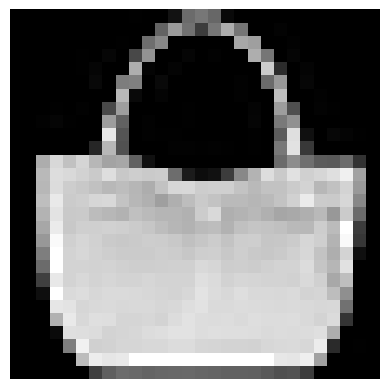

In [6]:
# 실제 이미지 확인
plt.imshow(X_train[100], cmap='gray')  # cmap='gray' : 흑백으로 출력
plt.axis('off')                        # x축, y축 눈금을 표시하지 않도록 설정
plt.show()


In [7]:
# 정답 확인 - 위에서 본 이미지가 몇 번 클래스인지 확인
# (위 분류표와 대조해보기 → 8 = 가방)
y_train[100]


np.uint8(8)

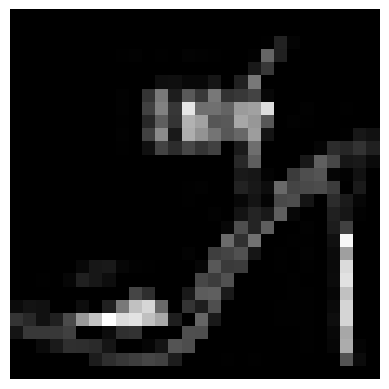

In [8]:
# 다른 이미지도 확인해보기
plt.imshow(X_train[1180], cmap='gray')
plt.axis('off')
plt.show()


In [9]:
# 정답 확인 (→ 5 = 샌들)
y_train[1180]


np.uint8(5)

### 3-2. 여러가지 이미지 확인 및 정답과 비교

- 위처럼 `plt.imshow()` + `y_train[]` 조합으로 **이미지와 정답이 맞는지 직접 눈으로 검증**한다
- 데이터를 학습시키기 전에 "내가 다루는 데이터가 무엇인지" 확인하는 습관이 중요하다


## 4. 신경망 설계 시 주의할 점 ⚠️

**1) 다차원 → 1차원 변환 필요**
- MLP층에서 `Dense`층을 사용할 때는 다차원 데이터를 쓸 수 없으므로 1차원으로 변경해야 한다
  - `reshape()`를 이용해 직접 데이터를 변경하는 방법
  - `Flatten` 층을 활용해 자동으로 1차원으로 변경하는 방법 👍

**2) 다중분류이므로 출력층 구조 주의**
- `units` : 정답의 종류만큼 → **10개**
- `activation` : **`softmax`** 사용
- softmax는 10개의 확률값을 출력하므로, 정수 1개인 기존 정답 데이터도 같은 형태로 바꿔야 한다
  → **원핫인코딩 진행**


### 4-1. softmax를 사용하므로 정답 데이터 원핫인코딩 진행

```
정답 8  →  [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
```
예측값(확률 10개)과 정답의 **모양(shape)을 맞춰주기 위한 작업**이다.


In [10]:
# 정답 데이터 원핫인코딩 진행
# pd.get_dummies() : 클래스마다 열을 만들어 해당 위치만 1, 나머지는 0
# dtype=int : True/False가 아닌 1/0 으로 저장
y_train_one_hot = pd.get_dummies(y_train, dtype=int)  # (60000,) → (60000, 10)
y_test_one_hot  = pd.get_dummies(y_test,  dtype=int)  # (10000,) → (10000, 10)


In [11]:
# 원핫인코딩이 잘 되어있는지 확인
# 각 행마다 1이 딱 한 개만 있으면 정상
y_train_one_hot.head()


,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0


## 5. 신경망 설계 진행 (여러가지 조합 비교)

- 여러 가지 **활성화 함수 + 최적화 함수** 조합으로 신경망을 설계한 후 성능을 비교한다
- **층 구조(units 64-128-64)와 epochs는 고정**하고 조합만 바꿔야 공정한 비교가 된다

| 조합 | activation | optimizer | 결과(val_accuracy) |
|:---:|---|---|---|
| 1번 | sigmoid | SGD | 약 0.71 |
| 2번 | (relu 등으로 바꿔서 비교해보기) | | |
| 3번 | | (Adam 등) | |


In [12]:
# 신경망 설계를 위한 도구 불러오기
from tensorflow.keras.models import Sequential   # 뼈대 생성을 도와주는 도구
from tensorflow.keras.layers import InputLayer   # 입력층을 쌓는 도구 중 하나
from tensorflow.keras.layers import Dense        # 중간층과 출력층을 쌓을 때 사용하는 도구
from tensorflow.keras.layers import Flatten      # 다차원 데이터를 1차원 데이터로 펴주는 도구


### 5-1. 1번 조합 : `activation = sigmoid` / `optimizer = SGD`

가장 기본이 되는 조합. **다른 조합과 비교할 기준점(baseline)** 으로 삼는다.


In [16]:
# ===== 1번 조합 : sigmoid + SGD =====

# 1. 뼈대 생성
model1 = Sequential()

# 2. 입력층 쌓기
# 입력할 데이터 1개의 형태 입력 - (28, 28)
model1.add(InputLayer(input_shape = (28, 28)))
# ※ 최신 keras에서는 input_shape 대신 shape 를 쓰라는 경고가 뜬다 → InputLayer(shape=(28,28))

# Dense층을 사용하기 위해 Flatten을 활용하여 1차원으로 데이터 변경 (28,28) → (784,)
model1.add(Flatten())

# 3. 중간층 쌓기 - 3개의 층 / units → 64, 128, 64 / activation → sigmoid
model1.add(Dense(64,  activation = 'sigmoid'))
model1.add(Dense(128, activation = 'sigmoid'))
model1.add(Dense(64,  activation = 'sigmoid'))

# 4. 출력층 - units는 정답의 종류(10개)
#    ※ 다중분류의 정석은 activation='softmax' 이다.
#      여기서는 sigmoid로 두고 돌려본 결과이며, softmax로 바꾸면 성능이 개선되는지 비교해볼 것!
model1.add(Dense(units = 10, activation = 'sigmoid'))

# 5. 학습방법 설정 (compile)
model1.compile(
    optimizer = 'SGD',                    # 최적화 함수 → SGD (방향 보정 X, 지그재그 발생)
    loss = 'categorical_crossentropy',    # 다중분류용 손실함수
    metrics = ['accuracy'])               # 평가지표 → 정확도

# 6. 학습 - epochs 30
model1.fit(
    X_train, y_train_one_hot,
    epochs = 30,
    validation_data = (X_test, y_test_one_hot))  # 테스트 데이터로 매 epoch마다 검증

# [결과] accuracy 약 0.717 / val_accuracy 약 0.707
# → MNIST(0.93)보다 확연히 낮다. 옷 이미지는 서로 비슷해서 훨씬 어려운 문제이기 때문


Epoch 1/30


c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3612 - loss: 2.1418 - val_accuracy: 0.4870 - val_loss: 1.8635
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5566 - loss: 1.5636 - val_accuracy: 0.6759 - val_loss: 1.3406
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6400 - loss: 1.1830 - val_accuracy: 0.6456 - val_loss: 1.0632
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 963us/step - accuracy: 0.6855 - loss: 0.9593 - val_accuracy: 0.7048 - val_loss: 0.8973
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7156 - loss: 0.8175 - val_accuracy: 0.7223 - val_loss: 0.7910
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7230 - loss: 0.7726 - val_accuracy: 0.7235 - val_loss: 0.7601
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7249 - loss: 0.7467 - val_accuracy: 0.7288 - val_loss: 0.7611
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7194 - loss: 0.7532 - val_accur

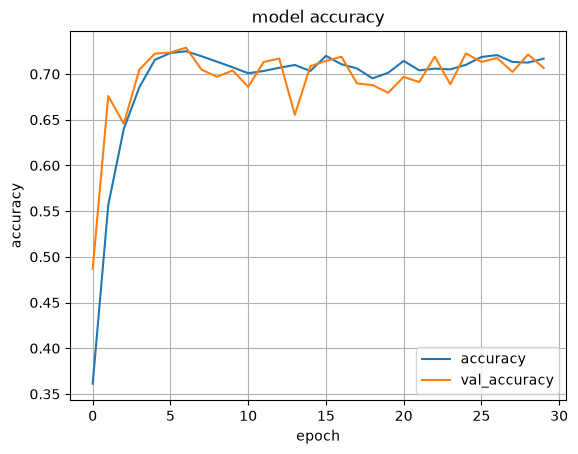

In [23]:
# 학습 결과 시각화
# model1.history.history : fit을 따로 변수에 담지 않아도 모델 안에 학습기록이 남는다
plt.plot(model1.history.history['accuracy'],     label = 'accuracy')      # 훈련 정확도
plt.plot(model1.history.history['val_accuracy'], label = 'val_accuracy')  # 검증 정확도
plt.grid(True)                    # 격자 표시
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc = 'lower right')   # 범례를 오른쪽 아래에 배치
plt.show()

# [보는 법]
# 두 선이 붙어서 상승 → 아직 과대적합 아님, 더 학습하거나 조합을 바꿔볼 여지가 있다
# acc↑ / val_acc↓ 로 벌어지면 → 과대적합(Overfitting)


## 6. 오늘의 정리

- **1번 조합(sigmoid + SGD)** 결과 : `accuracy 0.717 / val_accuracy 0.707`
- 같은 구조인데도 **MNIST(0.93)** 보다 성능이 확 낮다 → **데이터가 어려우면 모델도 어렵다**
- 성능을 올리기 위해 바꿔볼 수 있는 것들
  1. 활성화 함수 : `sigmoid` → **`relu`** (기울기 손실 완화)
  2. 최적화 함수 : `SGD` → **`Adam`** (방향 + 학습률 동시 보정)
  3. 출력층 : `sigmoid` → **`softmax`** (다중분류의 정석)
  4. 픽셀값 정규화 : `X_train / 255.0` (0~1 범위로 축소)
  5. epochs / units 수 조정
- 👉 한 번에 다 바꾸지 말고 **하나씩 바꿔가며 비교**해야 무엇이 효과가 있었는지 알 수 있다
